In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../analytics')

from correlate import load_closing_prices, compute_correlation

plt.rcParams['axes.facecolor']   = '#0f0f0f'
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.edgecolor']   = '#333'
plt.rcParams['axes.labelcolor']  = '#999'
plt.rcParams['xtick.color']      = '#666'
plt.rcParams['ytick.color']      = '#666'
plt.rcParams['text.color']       = '#e5e5e5'
plt.rcParams['grid.color']       = '#1a1a1a'

print("Setup complete")

Setup complete


In [21]:
tickers = ['AAPL', 'MSFT', 'TSLA', 'INFY']


prices = load_closing_prices(tickers)

print(f"Shape: {prices.shape}")
print(f"Date range: {prices.index[0]} → {prices.index[-1]}")
print(f"\nFirst 5 rows:")
print(prices.head())
print(f"\nBasic statistics:")
prices.describe().round(2)

Shape: (123, 4)
Date range: 2025-12-10 00:00:00 → 2026-06-08 00:00:00

First 5 rows:
                  AAPL        MSFT        TSLA       INFY
date                                                     
2025-12-10  278.263000  476.438263  451.450012  18.070000
2025-12-11  277.514404  481.326508  446.890015  17.799999
2025-12-12  277.763916  476.408417  458.959991  17.780001
2025-12-15  273.601654  472.714874  475.309998  17.780001
2025-12-16  274.100739  474.277924  489.880005  17.770000

Basic statistics:


,AAPL,MSFT,TSLA,INFY
count,123.00,123.00,123.00,123.00
mean,270.83,422.73,413.78,14.96
std,17.78,35.70,33.43,2.39
min,246.24,356.00,343.25,11.66
25%,258.61,399.22,391.58,12.93
50%,267.36,414.22,411.79,14.19
75%,275.69,453.57,435.79,17.78
max,315.20,485.86,489.88,20.22


In [22]:
returns = prices.pct_change().dropna()

print("Daily returns — first 5 rows:")
print(returns.head().round(4))

print(f"\nAverage daily return:")
for ticker in tickers:
    mean = returns[ticker].mean() * 100
    std  = returns[ticker].std()  * 100
    print(f"  {ticker}: {mean:.3f}% avg  |  {std:.3f}% std dev")

Daily returns — first 5 rows:
              AAPL    MSFT    TSLA    INFY
date                                      
2025-12-11 -0.0027  0.0103 -0.0101 -0.0149
2025-12-12  0.0009 -0.0102  0.0270 -0.0011
2025-12-15 -0.0150 -0.0078  0.0356  0.0000
2025-12-16  0.0018  0.0033  0.0307 -0.0006
2025-12-17 -0.0101 -0.0006 -0.0462  0.0253

Average daily return:
  AAPL: 0.076% avg  |  1.445% std dev
  MSFT: -0.100% avg  |  1.981% std dev
  TSLA: -0.049% avg  |  2.523% std dev
  INFY: -0.280% avg  |  2.711% std dev


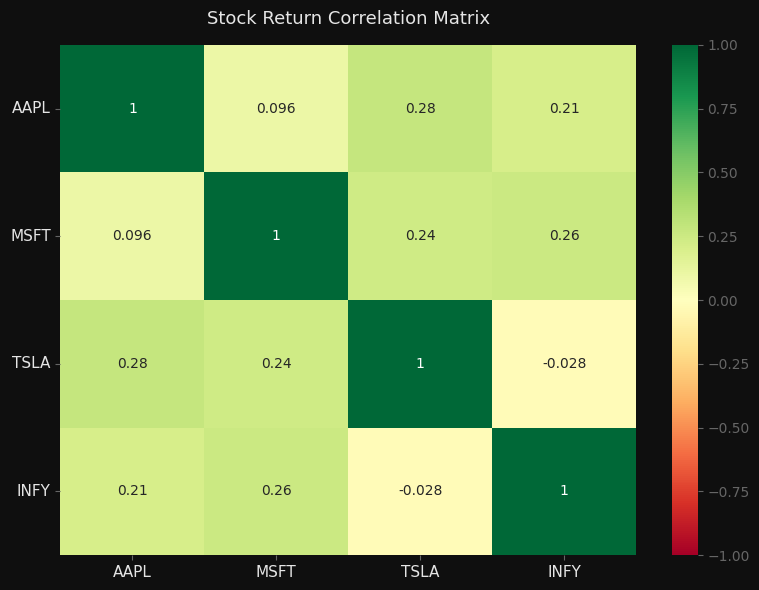

In [23]:
corr = returns.corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f0f0f')


sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1
)

ax.set_title('Stock Return Correlation Matrix', color='#e5e5e5', fontsize=13, pad=15)
ax.set_xticklabels(tickers, color='#e5e5e5', fontsize=11)
ax.set_yticklabels(tickers, color='#e5e5e5', fontsize=11, rotation=0)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



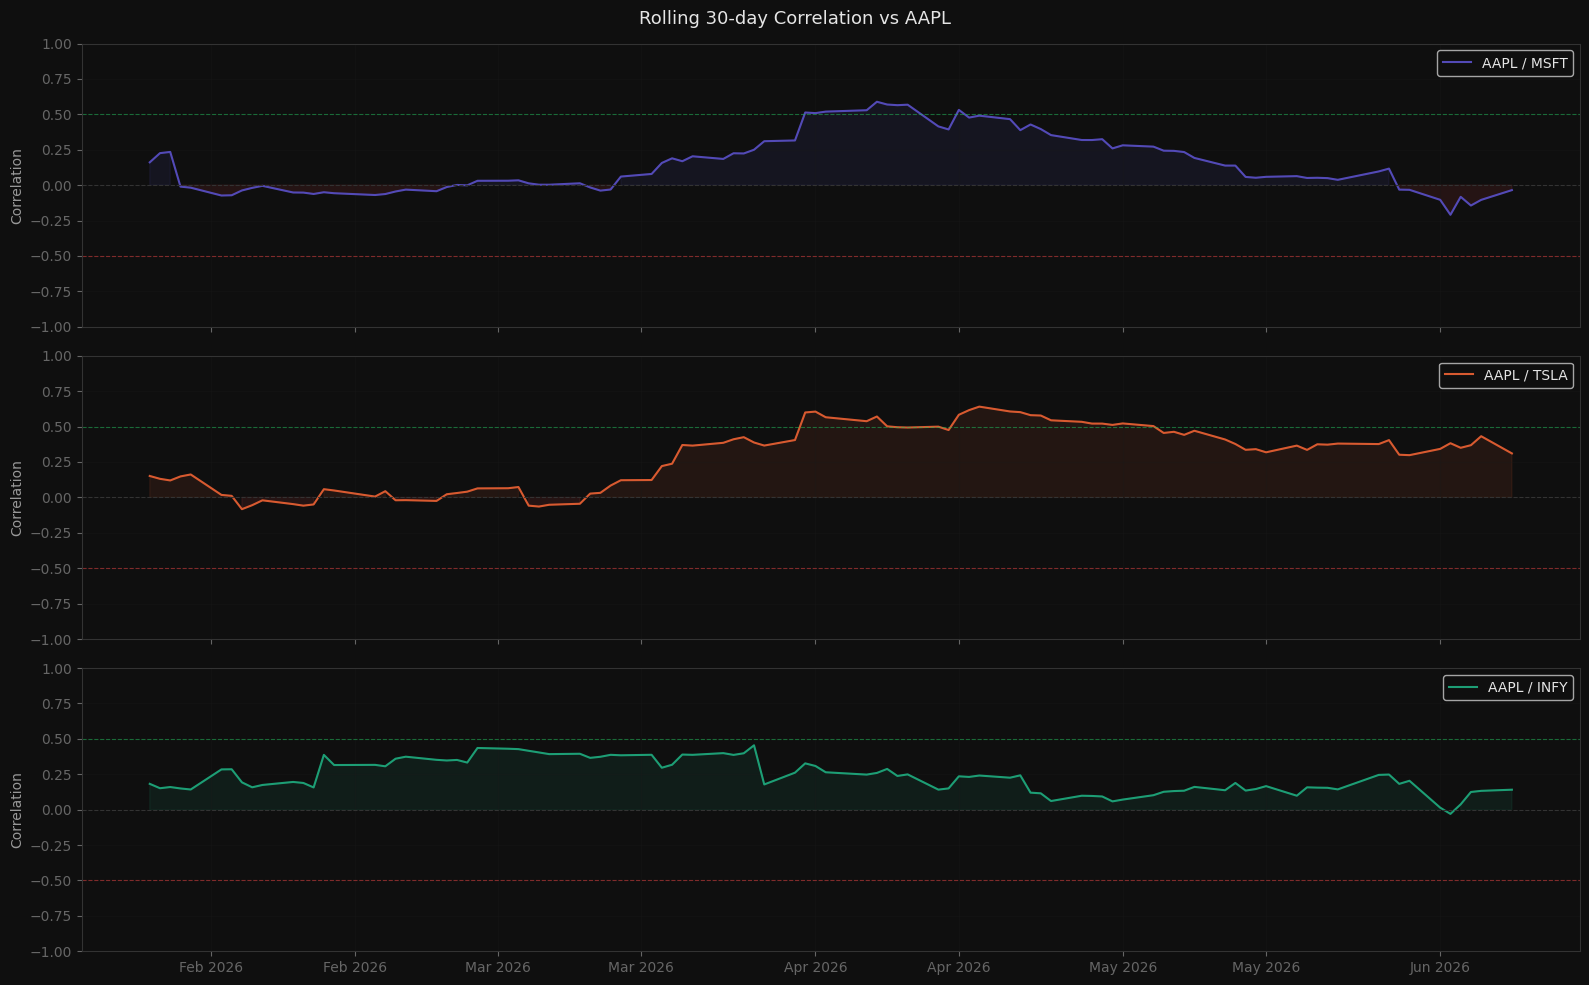

In [30]:

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Rolling 30-day Correlation vs AAPL', fontsize=13, color='#e5e5e5')
fig.patch.set_facecolor('#0f0f0f')

compare_tickers = ['MSFT', 'TSLA', 'INFY']
colors          = ['#534AB7', '#D85A30', '#1D9E75']

for ax, ticker, color in zip(axes, compare_tickers, colors):
    
    rolling_corr = returns['AAPL'].rolling(window=30).corr(returns[ticker])

    ax.set_facecolor('#0f0f0f')
    ax.plot(returns.index, rolling_corr, color=color, linewidth=1.5, label=f'AAPL / {ticker}')
    ax.axhline(y=0,    color='#333',    linewidth=0.8, linestyle='--')
    ax.axhline(y=0.5,  color='#22c55e', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(y=-0.5, color='#ef4444', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.fill_between(returns.index, rolling_corr, 0,
                    where=rolling_corr >= 0, color=color, alpha=0.1)
    ax.fill_between(returns.index, rolling_corr, 0,
                    where=rolling_corr < 0,  color='#ef4444', alpha=0.1)
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
result = compute_correlation(tickers)

pairs_df = pd.DataFrame(result['pairs'])
print("=== Correlation Pair Analysis ===\n")
print(pairs_df.to_string(index=False))

print(f"\nDate range: {result['date_range']['from']} → {result['date_range']['to']}")
print(f"Trading days analysed: {result['date_range']['days']}")

=== Correlation Pair Analysis ===

       pair  correlation  relationship
AAPL / TSLA        0.279 weak positive
MSFT / INFY        0.256 weak positive
MSFT / TSLA        0.238 weak positive
AAPL / INFY        0.206 weak positive
AAPL / MSFT        0.096 weak positive
TSLA / INFY       -0.028 weak negative

Date range: 2025-12-10 → 2026-06-08
Trading days analysed: 123


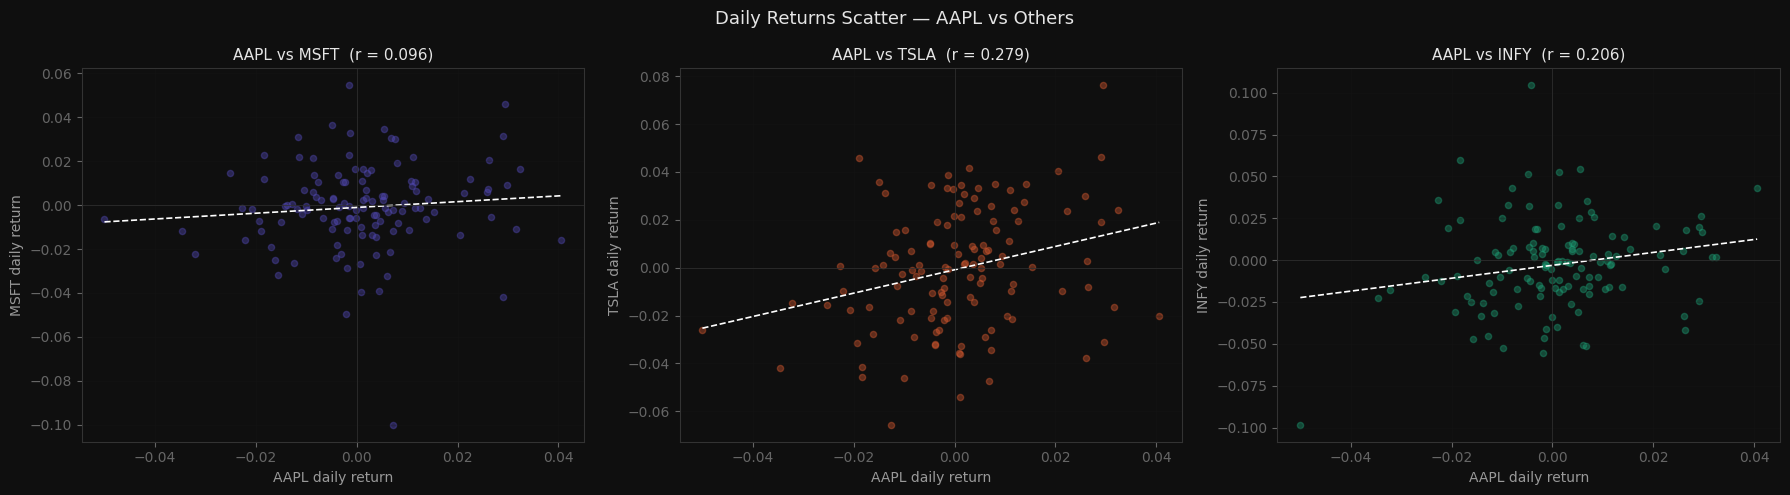

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Daily Returns Scatter — AAPL vs Others', fontsize=13, color='#e5e5e5')
fig.patch.set_facecolor('#0f0f0f')

compare = [('AAPL', 'MSFT', '#534AB7'),
           ('AAPL', 'TSLA', '#D85A30'),
           ('AAPL', 'INFY', '#1D9E75')]

for ax, (t1, t2, color) in zip(axes, compare):
    ax.set_facecolor('#0f0f0f')
    ax.scatter(returns[t1], returns[t2], color=color, alpha=0.4, s=20)

    # Trend line
    z = np.polyfit(returns[t1], returns[t2], 1)
    p = np.poly1d(z)
    x_line = np.linspace(returns[t1].min(), returns[t1].max(), 100)
    ax.plot(x_line, p(x_line), color='#fff', linewidth=1.2, linestyle='--')

    corr_val = returns[t1].corr(returns[t2])
    ax.set_title(f'{t1} vs {t2}  (r = {corr_val:.3f})', color='#e5e5e5', fontsize=11)
    ax.set_xlabel(f'{t1} daily return')
    ax.set_ylabel(f'{t2} daily return')
    ax.axhline(y=0, color='#333', linewidth=0.5)
    ax.axvline(x=0, color='#333', linewidth=0.5)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('returns_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("=" * 50)
print("CORRELATION ANALYSIS — KEY INSIGHTS")
print("=" * 50)

corr = returns.corr()

print("\n1. Strongest relationship:")
max_pair = result['pairs'][0]
print(f"   {max_pair['pair']} → {max_pair['correlation']} ({max_pair['relationship']})")

print("\n2. Weakest relationship:")
min_pair = result['pairs'][-1]
print(f"   {min_pair['pair']} → {min_pair['correlation']} ({min_pair['relationship']})")

print("\n3. Diversification insight:")
avg_corr = np.mean([p['correlation'] for p in result['pairs']])
print(f"   Average correlation across all pairs: {avg_corr:.3f}")
if avg_corr < 0.3:
    print("   These stocks are largely uncorrelated — good for diversification")
elif avg_corr < 0.6:
    print("   Moderate correlation — partial diversification benefit")
else:
    print("   High correlation — limited diversification benefit")

print("\n4. Individual volatility vs correlation:")
for ticker in tickers:
    vol  = returns[ticker].std() * np.sqrt(252) * 100
    print(f"   {ticker}: annualised volatility = {vol:.1f}%")

CORRELATION ANALYSIS — KEY INSIGHTS

1. Strongest relationship:
   AAPL / TSLA → 0.279 (weak positive)

2. Weakest relationship:
   TSLA / INFY → -0.028 (weak negative)

3. Diversification insight:
   Average correlation across all pairs: 0.174
   These stocks are largely uncorrelated — good for diversification

4. Individual volatility vs correlation:
   AAPL: annualised volatility = 22.9%
   MSFT: annualised volatility = 31.4%
   TSLA: annualised volatility = 40.0%
   INFY: annualised volatility = 43.0%
